# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

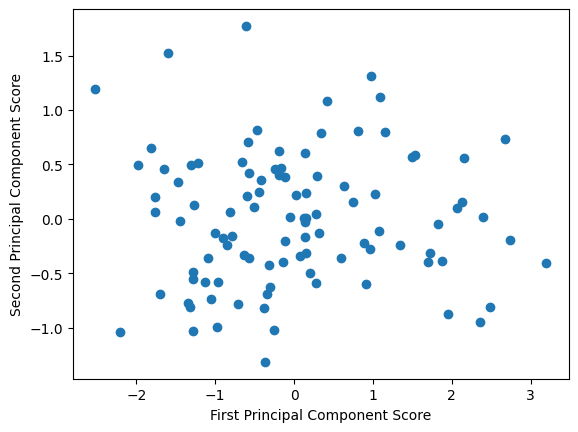

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

## Weekly Graph Question Answer

The three outliers in the upper left corner have a **low first principal component score** because they are positioned far to the left on the horizontal axis. They also have a **high second principal component score** because they are located high on the vertical axis.

This means that these observations differ from the rest of the data in both principal component directions. Since the second principal component is strongly influenced by series_3, these outliers likely have unusually high values in series_3 compared to the rest of the observations.

However, it is much harder to make precise statements about series_1 and series_2 individually. This is because principal components are linear combinations of the original variables, so each component mixes information from multiple variables. As a result, we cannot directly isolate the exact contribution of series_1 versus series_2 just from the score plot.

Additionally, series_1 and series_2 are likely correlated or constructed in a way that makes them difficult to distinguish independently after transformation. PCA rotates the coordinate system to maximize variance, which can make interpretation of individual original variables less straightforward.

Overall, the graph is useful because it reduces the data into two dimensions and helps visualize structure and identify outliers. However, a limitation is that it does not clearly show the contribution of each original variable without examining the loadings.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import kagglehub
# Optional display settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [7]:

path = kagglehub.dataset_download("datasetengineer/logistics-and-supply-chain-dataset")
print("Dataset folder:", path)

csv_files = glob.glob(os.path.join(path, "*.csv"))
print("CSV files found:", csv_files)

df = pd.read_csv(csv_files[0])
df.head()

100%|██████████| 6.89M/6.89M [00:00<00:00, 68.4MB/s]

Extracting files...
Dataset folder: /home/codespace/.cache/kagglehub/datasets/datasetengineer/logistics-and-supply-chain-dataset/versions/1
CSV files found: ['/home/codespace/.cache/kagglehub/datasets/datasetengineer/logistics-and-supply-chain-dataset/versions/1/dynamic_supply_chain_logistics_dataset.csv']


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,0.359066,4.289160,456.503853,0.986064,2.128009,100.772854,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,0.230660,7.018373,640.408205,0.463233,12.608166,5313.738114,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,0.027210,9.605064,155.749314,0.598561,14.124452,1595.049146,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,0.616619,8.899616,104.317961,0.742735,3.818972,2530.431941,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,0.952385,0.061760,977.222528,0.431088,14.001491,2146.190197,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [8]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (32065, 26)

Columns:
['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  str    
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs               

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,32065,32065,2021-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_gps_latitude,32065.0,NaN,NaN,NaN,38.023589,6.917909,30.0,31.28055,36.41382,44.453655,50.0
vehicle_gps_longitude,32065.0,NaN,NaN,NaN,-90.116648,17.369244,-119.999998,-106.253913,-86.293414,-73.079367,-70.0
fuel_consumption_rate,32065.0,NaN,NaN,NaN,8.011735,4.26496,5.0,5.019984,5.636036,9.669944,19.999875
eta_variation_hours,32065.0,NaN,NaN,NaN,2.893068,2.274044,-1.999993,1.185744,3.882059,4.884355,5.0
traffic_congestion_level,32065.0,NaN,NaN,NaN,4.991493,3.532048,0.0,1.47472,4.981244,8.534902,9.999999
warehouse_inventory_level,32065.0,NaN,NaN,NaN,299.254732,323.443513,0.0,16.051635,157.288022,540.597991,999.999298
loading_unloading_time,32065.0,NaN,NaN,NaN,2.291669,1.554202,0.5,0.774798,1.917121,3.734188,5.0
handling_equipment_availability,32065.0,NaN,NaN,NaN,0.302695,0.325915,0.0,0.017108,0.159515,0.553595,0.999999
order_fulfillment_status,32065.0,NaN,NaN,NaN,0.60074,0.345672,0.000001,0.277096,0.680553,0.93816,1.0


In [11]:

candidate_numeric_cols = [
    "vehicle_gps_latitude",
    "vehicle_gps_longitude",
    "fuel_consumption_rate",
    "eta_variation_hours",
    "traffic_congestion_level",
    "warehouse_inventory_level",
    "loading_unloading_time",
    "handling_equipment_availability",
    "port_congestion_level",
    "shipping_costs",
    "supplier_reliability_score",
    "lead_time_days",
    "historical_demand",
    "iot_temperature",
    "weather_condition_severity",
    "customs_clearance_time",
    "driver_behavior_score",
    "fatigue_monitoring_score",
    "disruption_likelihood_score",
    "delay_probability",
    "year",
    "month",
    "day",
    "hour"
]

numeric_cols = [col for col in candidate_numeric_cols if col in df.columns]
print("Numeric columns used:")
numeric_cols

Numeric columns used:


['vehicle_gps_latitude',
 'vehicle_gps_longitude',
 'fuel_consumption_rate',
 'eta_variation_hours',
 'traffic_congestion_level',
 'warehouse_inventory_level',
 'loading_unloading_time',
 'handling_equipment_availability',
 'port_congestion_level',
 'shipping_costs',
 'supplier_reliability_score',
 'lead_time_days',
 'historical_demand',
 'iot_temperature',
 'weather_condition_severity',
 'customs_clearance_time',
 'driver_behavior_score',
 'fatigue_monitoring_score',
 'disruption_likelihood_score',
 'delay_probability']

In [12]:
# -------------------------
# Build numeric dataframe
# -------------------------
X = df[numeric_cols].copy()

# Impute missing values with median
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_imputed.head()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,weather_condition_severity,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability
0,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,4.289160,456.503853,0.986064,2.128009,100.772854,0.574400,0.359066,0.502006,0.033843,0.978599,0.506152,0.885291
1,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,7.018373,640.408205,0.463233,12.608166,5313.738114,-9.753493,0.230660,0.966774,0.201725,0.918586,0.980784,0.544178
2,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,9.605064,155.749314,0.598561,14.124452,1595.049146,-6.491034,0.027210,0.945627,0.264045,0.394215,0.998633,0.803322
3,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,8.899616,104.317961,0.742735,3.818972,2530.431941,-0.151276,0.616619,4.674035,0.362885,0.905444,0.993320,0.025977
4,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.061760,977.222528,0.431088,14.001491,2146.190197,2.429448,0.952385,3.445429,0.016957,0.258702,0.912433,0.991122


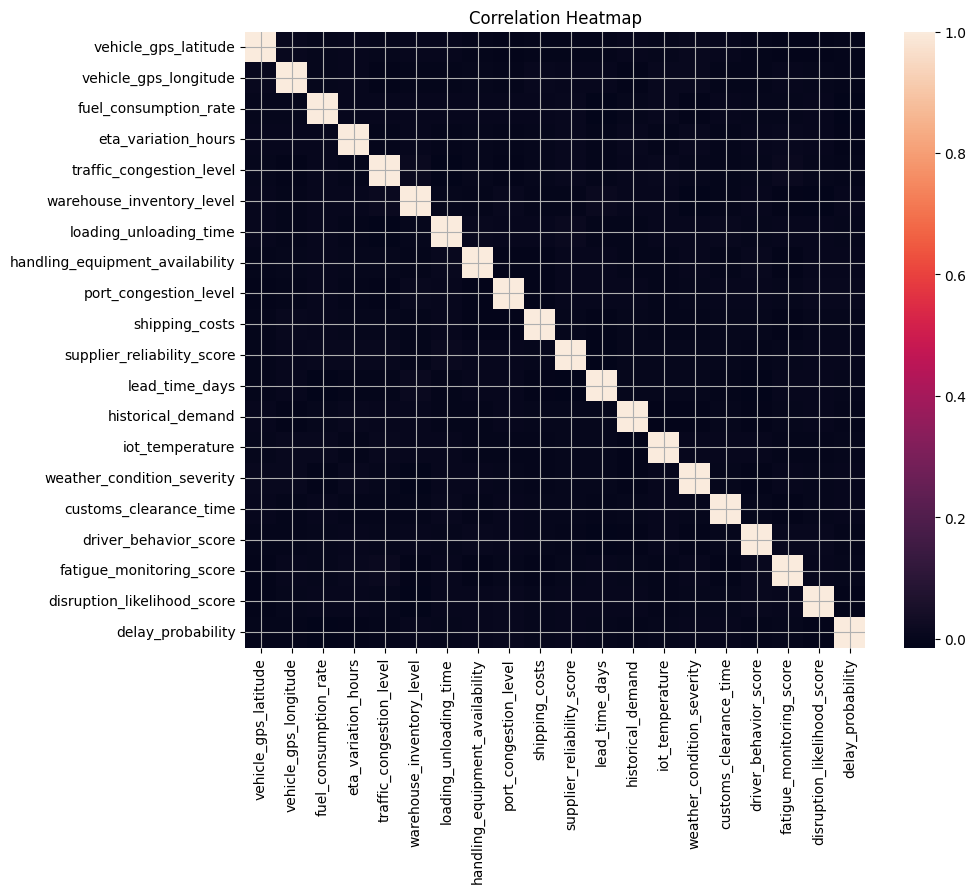

In [13]:
# -------------------------
# Correlation heatmap
# -------------------------
corr_matrix = X_imputed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False)
plt.title("Correlation Heatmap")
plt.show()

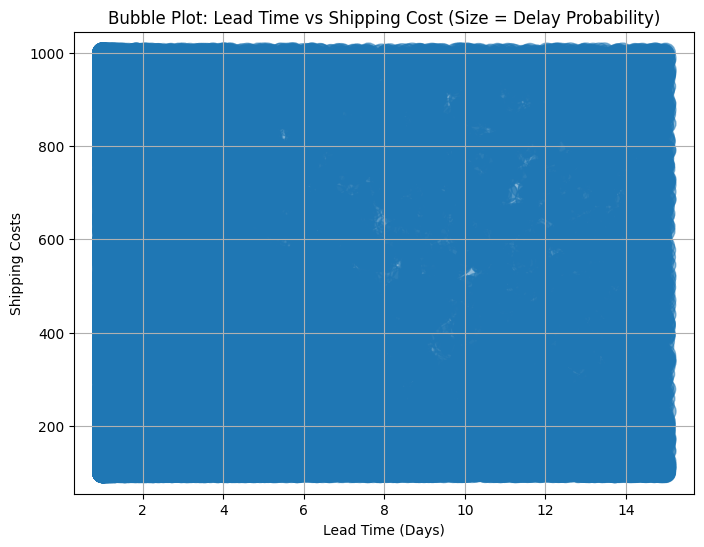

In [14]:
# -------------------------
# Bubble plot
# -------------------------
# This will run only if these columns exist
if all(col in X_imputed.columns for col in ["lead_time_days", "shipping_costs", "delay_probability"]):
    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_imputed["lead_time_days"],
        X_imputed["shipping_costs"],
        s=X_imputed["delay_probability"] * 200,
        alpha=0.5
    )
    plt.xlabel("Lead Time (Days)")
    plt.ylabel("Shipping Costs")
    plt.title("Bubble Plot: Lead Time vs Shipping Cost (Size = Delay Probability)")
    plt.show()
else:
    print("Bubble plot columns not found in dataset.")

In [15]:
# -------------------------
# Standardize data for PCA
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_scaled[:5]

array([[ 0.33998946,  0.75435259, -0.67416057,  0.92565231,  0.26503242,
         2.12238863,  1.71133776,  0.5479995 , -0.82720824, -0.00919537,
         1.37251314, -0.68527157, -1.7275222 ,  0.03732982, -0.39215972,
        -1.15330827, -1.31171364,  1.09231084, -1.06563285,  0.57383362],
       [-0.65277544, -1.54990478, -0.68236719, -0.83910795, -0.9624881 ,
         0.30127979, -0.81154815,  0.97599166,  0.01229145,  0.5799044 ,
        -0.10640593,  1.63180192, -0.20663624, -0.69063945, -0.75562948,
        -0.85459674, -0.83767635,  0.91876583,  0.63445891, -0.47733359],
       [-1.15686315,  0.85482448, -0.68487813,  0.91450718,  1.07482444,
         1.64839452,  1.24088796,  1.55944497,  0.80795135, -0.97260068,
         0.27639156,  1.96703982, -1.29156613, -0.46068257, -1.33151702,
        -0.86818848, -0.66170849, -0.59761305,  0.69839149,  0.32123941],
       [-0.198671  ,  1.14722488,  0.04872865,  0.08882796, -1.40040945,
        -0.92345678, -1.13338589, -0.90261342,  

In [16]:
# -------------------------
# PCA
# -------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance
})

pca_summary

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.051984,0.051984
1,PC2,0.051648,0.103632
2,PC3,0.051542,0.155174
3,PC4,0.051415,0.206589
4,PC5,0.050975,0.257563
5,PC6,0.050750,0.308313
6,PC7,0.050716,0.359029
7,PC8,0.050552,0.409581
8,PC9,0.050420,0.460002
9,PC10,0.050321,0.510323


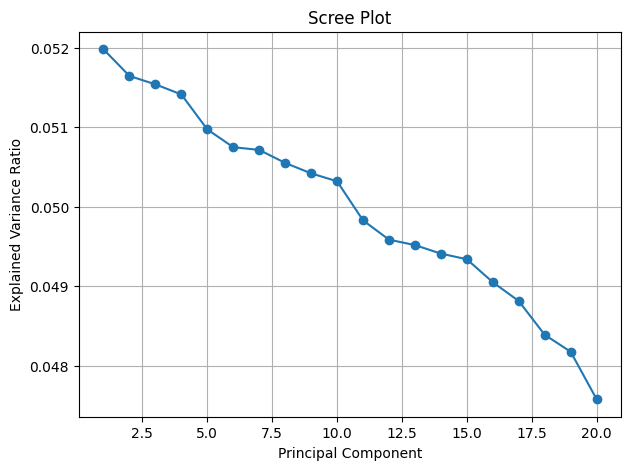

In [17]:
# -------------------------
# Scree plot
# -------------------------
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

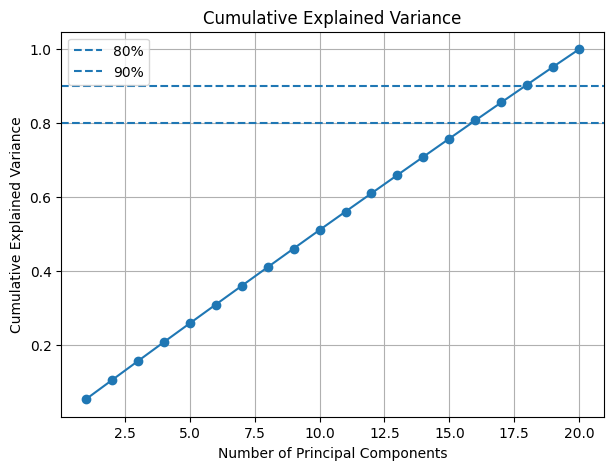

In [18]:
# -------------------------
# Cumulative explained variance plot
# -------------------------
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.80, linestyle="--", label="80%")
plt.axhline(y=0.90, linestyle="--", label="90%")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()

In [19]:
# -------------------------
# Variance explained by PC1
# -------------------------
pc1_variance = explained_variance_ratio[0]
print("Variance explained by PC1:", pc1_variance)

Variance explained by PC1: 0.051984071450590974


In [20]:
# -------------------------
# Variance explained by PC1
# -------------------------
pc1_variance = explained_variance_ratio[0]
print("Variance explained by PC1:", pc1_variance)

Variance explained by PC1: 0.051984071450590974


In [22]:
# -------------------------
# PCA loadings
# -------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols,
    columns=[f"PC{i+1}" for i in range(len(numeric_cols))]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
vehicle_gps_latitude,-0.000490,0.258574,0.394236,-0.022688,0.203983,0.299384,0.106030,-0.037926,-0.353277,0.114913,0.044268,-0.255647,-0.318334,-0.055768,-0.127326,0.332366,-0.132631,-0.383950,0.099095,0.148334
vehicle_gps_longitude,-0.142351,0.384771,0.191506,-0.159106,-0.094736,-0.264565,-0.112571,-0.219622,0.314688,0.175438,-0.249627,-0.291763,-0.163638,0.132315,0.005586,0.240788,0.369214,0.201738,-0.087434,-0.256164
fuel_consumption_rate,-0.332520,-0.320795,0.199064,0.167279,0.025847,0.093519,0.042880,-0.267794,0.199516,-0.184843,0.026305,0.359705,-0.193846,0.325286,0.172571,0.287140,-0.099074,-0.002567,0.370779,-0.170223
eta_variation_hours,-0.242323,0.040288,0.004833,-0.292529,0.281720,0.053579,0.135591,-0.230504,0.041948,0.425611,-0.045231,0.334794,0.453346,0.117209,-0.222391,0.010912,-0.114760,-0.214595,-0.252462,-0.107119
traffic_congestion_level,-0.002259,-0.357264,0.155235,-0.330640,-0.220589,0.103698,0.311150,0.235662,0.004921,-0.355918,-0.047658,-0.011462,-0.077091,-0.102968,-0.335273,0.132627,0.206962,-0.115043,-0.284806,-0.338146
warehouse_inventory_level,0.372725,-0.325640,0.274865,0.028439,-0.040889,0.195233,0.053764,-0.225218,0.219580,0.302368,0.089780,0.017633,0.052386,-0.156651,-0.283590,0.139921,0.126681,0.415605,0.067896,0.341452
loading_unloading_time,-0.188180,0.126592,-0.111884,0.471471,0.049077,0.212189,0.096774,-0.081052,0.145566,0.032205,0.593849,-0.156629,0.103547,-0.252543,-0.045327,0.090301,0.116173,0.041396,-0.188784,-0.339733
handling_equipment_availability,-0.124257,0.026072,-0.187412,0.109781,-0.066794,0.585658,-0.336480,0.233230,0.210141,-0.036073,-0.217816,0.038739,0.078060,0.219570,0.036499,0.157173,0.316909,-0.155453,-0.202809,0.284886
port_congestion_level,0.215136,-0.140730,-0.344429,0.219826,0.160917,-0.180113,0.220402,-0.362958,0.051009,0.047354,-0.205506,0.172066,-0.393052,-0.176912,0.091183,0.061528,0.232144,-0.328136,-0.283807,0.107820
shipping_costs,-0.145338,-0.032694,0.250955,0.134777,0.078244,-0.532029,-0.299398,0.272845,0.099986,-0.069073,0.220466,0.221294,0.105028,-0.163641,-0.219226,0.188697,0.227459,-0.279105,0.029989,0.281154


In [23]:
# -------------------------
# Top contributors to PC1 and PC2
# -------------------------
pc1_loadings = loadings["PC1"].sort_values(key=np.abs, ascending=False)
pc2_loadings = loadings["PC2"].sort_values(key=np.abs, ascending=False)

print("Top contributors to PC1:")
display(pc1_loadings.head(10))

print("Top contributors to PC2:")
display(pc2_loadings.head(10))

Top contributors to PC1:


lead_time_days                 0.466005
warehouse_inventory_level      0.372725
fuel_consumption_rate         -0.332520
supplier_reliability_score    -0.319066
delay_probability              0.319051
disruption_likelihood_score   -0.246535
eta_variation_hours           -0.242323
port_congestion_level          0.215136
loading_unloading_time        -0.188180
driver_behavior_score         -0.183216
Name: PC1, dtype: float64

Top contributors to PC2:


weather_condition_severity    0.485530
vehicle_gps_longitude         0.384771
traffic_congestion_level     -0.357264
warehouse_inventory_level    -0.325640
fuel_consumption_rate        -0.320795
driver_behavior_score        -0.300040
vehicle_gps_latitude          0.258574
historical_demand            -0.193120
lead_time_days                0.160879
port_congestion_level        -0.140730
Name: PC2, dtype: float64

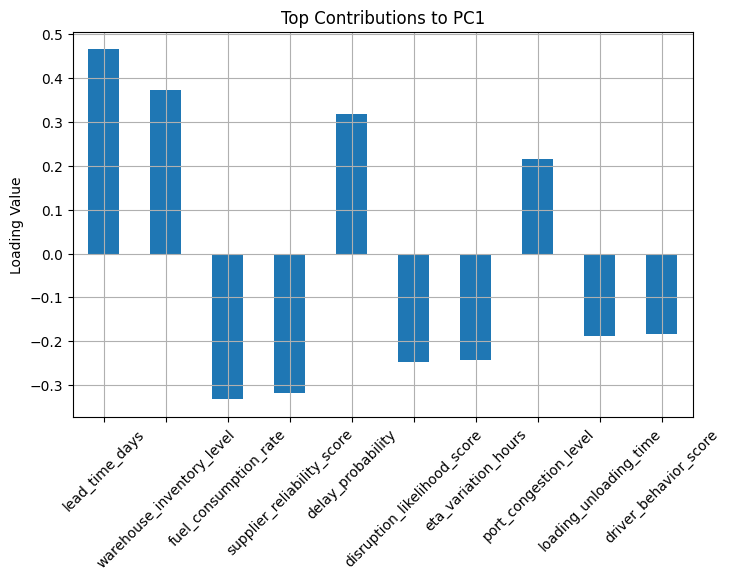

In [24]:

pc1_loadings.head(10).plot(kind="bar")
plt.title("Top Contributions to PC1")
plt.ylabel("Loading Value")
plt.xticks(rotation=45)
plt.show()

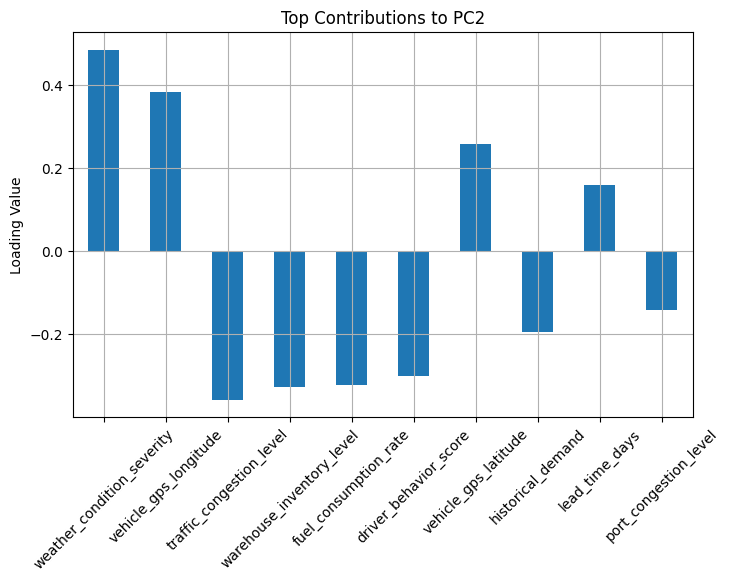

In [25]:
pc2_loadings.head(10).plot(kind="bar")
plt.title("Top Contributions to PC2")
plt.ylabel("Loading Value")
plt.xticks(rotation=45)
plt.show()

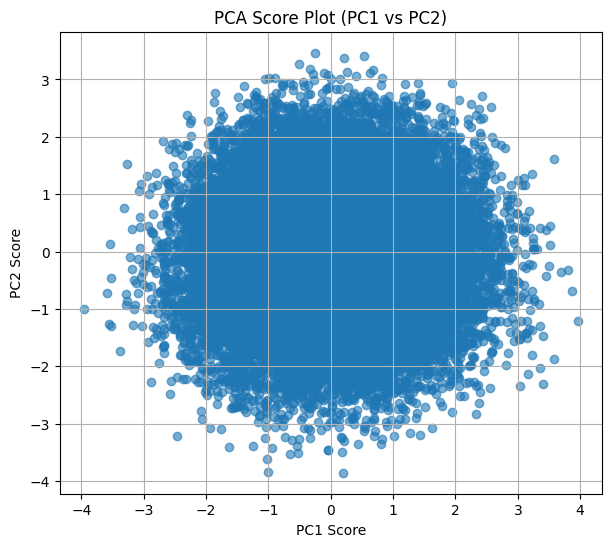

In [26]:
# -------------------------
# PCA score plot
# -------------------------
scores_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])

plt.figure(figsize=(7, 6))
plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.6)
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.title("PCA Score Plot (PC1 vs PC2)")
plt.show()

In [27]:
# -------------------------
# Outlier detection in PCA space
# -------------------------
scores_df["distance_from_origin"] = np.sqrt(scores_df["PC1"]**2 + scores_df["PC2"]**2)
outliers = scores_df.sort_values("distance_from_origin", ascending=False).head(10)

outliers

,PC1,PC2,distance_from_origin
20217,3.958899,-1.213828,4.140805
22945,3.397269,-2.304447,4.105108
17913,-3.952097,-0.995077,4.075445
17472,-2.466956,-3.208309,4.047112
23861,3.584831,-1.872988,4.044638
6937,-1.015451,-3.852004,3.983601
17287,3.865501,-0.687792,3.926214
13017,3.578211,1.609324,3.923458
11204,3.352182,-2.030597,3.919240
3519,0.188013,-3.857199,3.861778


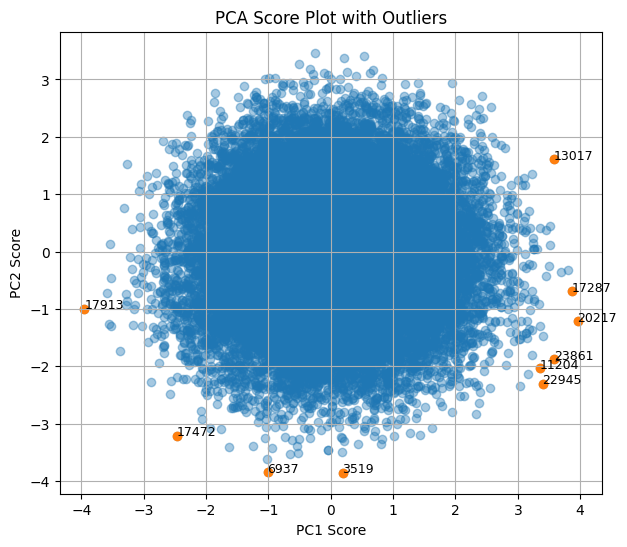

In [28]:
# -------------------------
# PCA score plot with outliers
# -------------------------
plt.figure(figsize=(7, 6))
plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.4)
plt.scatter(outliers["PC1"], outliers["PC2"], alpha=1.0)

for idx, row in outliers.iterrows():
    plt.text(row["PC1"], row["PC2"], str(idx), fontsize=9)

plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.title("PCA Score Plot with Outliers")
plt.show()

In [30]:
# -------------------------
# Inspect original rows for outliers
# -------------------------
df.loc[outliers.index]

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
20217,2023-04-23 09:00:00,30.301283,-113.568498,5.000000,-1.599758,0.136582,984.934499,1.370386,0.474825,0.002002,0.276509,9.245707,369.337322,0.000915,13.839353,9260.719575,21.087457,0.433110,9.635875,2.129805,0.808950,0.465953,0.188305,0.878344,Low Risk,-1.298939
22945,2023-08-15 01:00:00,38.294691,-118.649839,7.363159,-0.011442,9.743769,982.116937,1.959215,0.413800,0.784656,0.071301,9.269918,452.072020,0.024771,10.963855,9999.993614,-9.991211,0.069070,9.999969,0.524955,0.378986,0.101559,0.564344,0.843686,Moderate Risk,-1.945427
17913,2023-01-17 09:00:00,36.004635,-98.039966,19.538003,4.992526,0.012227,5.556675,4.971573,0.968694,0.046783,0.190475,4.336635,311.974684,0.955142,1.043614,2463.385973,-9.589876,0.602284,3.787248,0.514250,0.974310,0.510493,0.971586,0.072503,High Risk,5.378264
17472,2022-12-30 00:00:00,32.827800,-117.030721,19.603249,4.921244,7.471043,0.045156,0.524030,0.400991,0.425559,0.148073,7.176104,835.176096,0.816799,1.730653,9012.854604,-6.450163,0.574286,7.878156,0.834537,0.992439,0.957190,0.999923,0.447885,High Risk,-0.466538
23861,2023-09-22 05:00:00,30.131942,-107.456779,5.203897,-1.711556,9.961028,936.408130,0.930805,0.048394,0.983790,0.265266,9.097462,393.756621,0.005818,13.783038,7524.121514,-1.091142,0.211266,9.999941,0.819353,0.427642,0.855447,0.926678,0.999413,High Risk,6.568290
6937,2021-10-17 01:00:00,30.034742,-113.469841,19.333598,4.982475,9.763118,946.539452,1.392846,0.033077,0.014323,0.027510,0.422156,789.844618,0.881142,2.835289,7175.460886,-9.664515,0.005866,9.999723,2.189725,0.930249,0.672747,0.903384,0.994711,High Risk,0.205719
17287,2022-12-22 07:00:00,48.011882,-108.683799,5.003467,1.524902,8.210100,974.190266,1.196823,0.108862,0.682690,0.368021,9.344590,112.216174,0.234264,14.980657,8919.987211,-6.222781,0.002880,2.753254,2.265260,0.318395,0.020251,0.737679,0.988384,High Risk,8.916102
13017,2022-06-27 09:00:00,48.712507,-70.625291,5.001440,-1.024767,9.340750,709.183501,2.100986,0.000017,0.684941,0.917365,9.709650,360.393492,0.352857,14.393867,4267.064601,-10.000000,0.013151,9.103895,3.943415,0.059256,0.402604,0.013380,0.984432,Low Risk,4.762628
11204,2022-04-12 20:00:00,47.075244,-110.266899,5.013274,-1.683136,6.960320,926.079379,0.500370,0.183671,0.999260,0.003499,9.445520,320.056275,0.693061,12.272052,7963.733569,-9.965744,0.457986,9.978221,0.807176,0.999658,0.036954,0.332018,0.863973,Moderate Risk,9.647687
3519,2021-05-27 15:00:00,35.475820,-118.126678,18.901555,4.991913,6.401536,988.398523,1.739299,0.002662,0.429562,0.004281,9.114289,206.147849,0.196972,1.067505,8224.669095,-9.915751,0.451958,2.498811,0.551020,0.999997,0.976347,0.996322,0.999704,High Risk,0.004939


In [31]:
# -------------------------
# Linear regression
# Predict delay_probability
# -------------------------
if "delay_probability" in X_imputed.columns:
    features = [col for col in numeric_cols if col != "delay_probability"]

    X_model = X_imputed[features]
    y_model = X_imputed["delay_probability"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_model, y_model, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("RMSE:", rmse)
    print("R^2:", r2)
else:
    print("delay_probability column not found.")

RMSE: 0.3213751900375984
R^2: -0.0007494122303162154


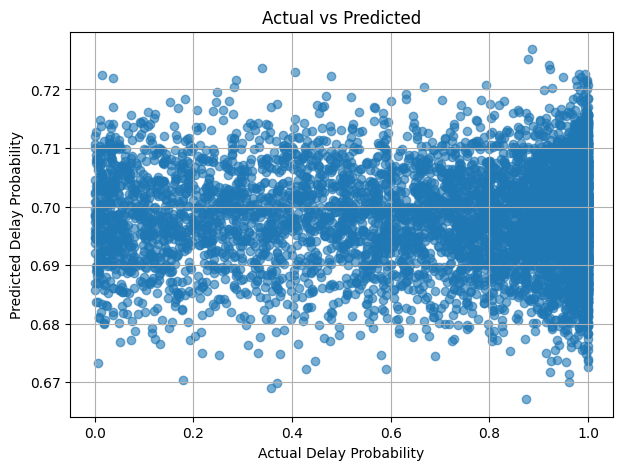

In [32]:
# -------------------------
# Actual vs predicted plot
# -------------------------
if "delay_probability" in X_imputed.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Delay Probability")
    plt.ylabel("Predicted Delay Probability")
    plt.title("Actual vs Predicted")
    plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

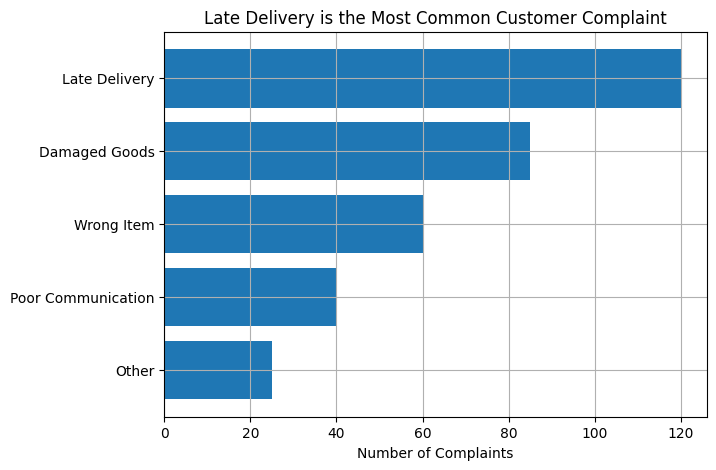

In [37]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create simple generic data
categories = [
    "Late Delivery",
    "Damaged Goods",
    "Wrong Item",
    "Poor Communication",
    "Other"
]

values = [120, 85, 60, 40, 25]

df_plot = pd.DataFrame({
    "Category": categories,
    "Count": values
})

# Sort for better storytelling
df_plot = df_plot.sort_values("Count", ascending=True)

# Plot
plt.figure(figsize=(7,5))

plt.barh(df_plot["Category"], df_plot["Count"])

plt.xlabel("Number of Complaints")
plt.title("Late Delivery is the Most Common Customer Complaint")

plt.show()